<a href="https://colab.research.google.com/github/kshitij-nandanwar/NNDL-Lab/blob/main/NNDL_Practical_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

In [1]:
import os, re, tarfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, roc_curve,
                             confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

print("TensorFlow", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow 2.21.0
GPU available: True


## 2. Load the IMDB reviews

The cell downloads the original archive (~80 MB) from Stanford and reads every review file.
If the download fails it falls back to the copy bundled with Keras (same reviews, but already lower-cased and stripped of punctuation).

In [2]:
URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
BASE = "aclImdb"

def download_imdb():
    if os.path.isdir(BASE):
        return True
    try:
        print("Downloading IMDB dataset ...")
        urllib.request.urlretrieve(URL, "aclImdb_v1.tar.gz")
        with tarfile.open("aclImdb_v1.tar.gz") as tar:
            tar.extractall(".")
        return True
    except Exception as e:
        print("Download failed:", e)
        return False

def read_split(split):
    texts, labels = [], []
    for label, cls in enumerate(["neg", "pos"]):
        folder = os.path.join(BASE, split, cls)
        for fn in sorted(os.listdir(folder)):
            with open(os.path.join(folder, fn), encoding="utf-8") as f:
                texts.append(f.read())
            labels.append(label)
    return texts, np.array(labels)

def load_from_keras():
    (xtr, ytr), (xte, yte) = keras.datasets.imdb.load_data()
    word_index = keras.datasets.imdb.get_word_index()
    inv = {v + 3: k for k, v in word_index.items()}
    inv.update({0: "", 1: "", 2: "unk", 3: "unk"})
    decode = lambda seq: " ".join(inv.get(i, "unk") for i in seq).strip()
    return [decode(s) for s in xtr], ytr, [decode(s) for s in xte], yte

if download_imdb():
    train_texts, train_labels = read_split("train")
    test_texts, test_labels = read_split("test")
else:
    train_texts, train_labels, test_texts, test_labels = load_from_keras()

print(f"Train reviews: {len(train_texts):,} | Test reviews: {len(test_texts):,}")

Train reviews: 25,000 | Test reviews: 25,000


In [3]:
df_train = pd.DataFrame({"text": train_texts, "label": train_labels})
df_train["sentiment"] = df_train["label"].map({0: "negative", 1: "positive"})
df_train["n_words"] = df_train["text"].str.split().str.len()

print(df_train["sentiment"].value_counts())
print()
for lab in ["positive", "negative"]:
    ex = df_train[df_train.sentiment == lab].sample(1, random_state=1).iloc[0]
    print(f"[{lab.upper()}] {ex.text[:400]} ...\n")

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

[POSITIVE] What a pleasant surprise: A Disney DTV (Direct to Video) sequel that's actually GOOD. "The Lion King 1 1/2" is a comedy affair that involves everyone's favorite meerkat and warthog, Timon and Pumbaa. It starts out with them watching the original movie and making comments, until Timon complains that "we're not here yet". After fighting over the remote, Timon and Pumbaa decide to tell the audience " ...

[NEGATIVE] After seeing the 1996 remake, I thought it was the funniest way to see Cruella De Vil getting her punishment for torturing animals just for their skin. The whole movie was quite funny, and on my view, better than the animated one. But there was actually no need for a second one. First of all, if Cruela is returning, don't cure her and make her insane again. Just make her break away from jail and t ...



## 3. Exploratory data analysis

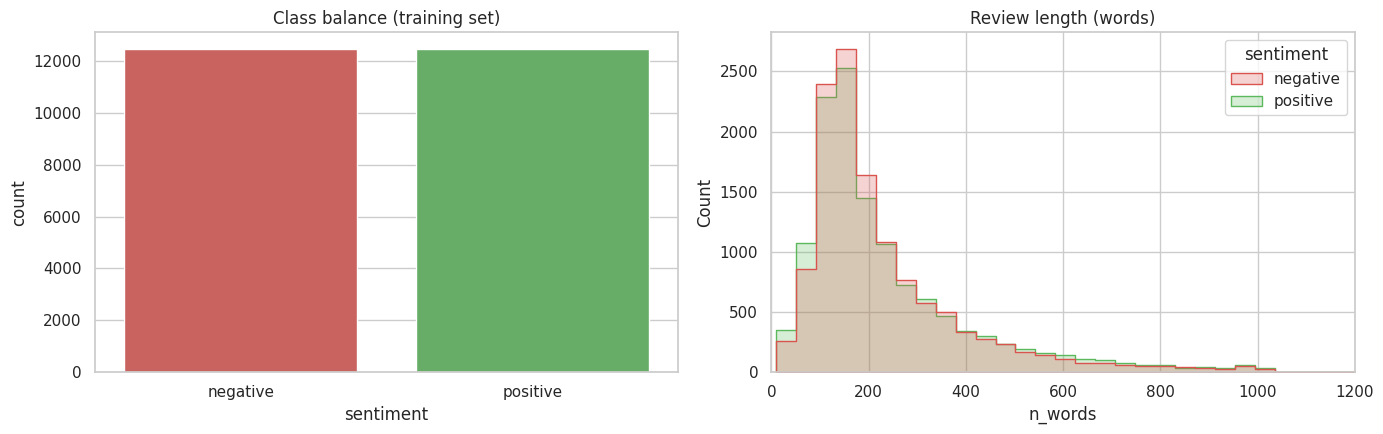

count    25000.0
mean       233.8
std        173.7
min         10.0
25%        127.0
50%        174.0
75%        284.0
max       2470.0
Name: n_words, dtype: float64
Reviews fully covered by MAX_LEN=128: 26.2%
Reviews fully covered by MAX_LEN=200: 58.6%
Reviews fully covered by MAX_LEN=256: 70.8%
Reviews fully covered by MAX_LEN=400: 86.6%
Reviews fully covered by MAX_LEN=500: 91.9%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_train, x="sentiment", palette=["#d9534f", "#5cb85c"], ax=axes[0])
axes[0].set_title("Class balance (training set)")

sns.histplot(data=df_train, x="n_words", hue="sentiment", bins=60, element="step",
             palette=["#d9534f", "#5cb85c"], ax=axes[1])
axes[1].set_xlim(0, 1200)
axes[1].set_title("Review length (words)")
plt.tight_layout(); plt.show()

print(df_train["n_words"].describe().round(1))
for L in [128, 200, 256, 400, 500]:
    print(f"Reviews fully covered by MAX_LEN={L}: {(df_train['n_words'] <= L).mean():.1%}")

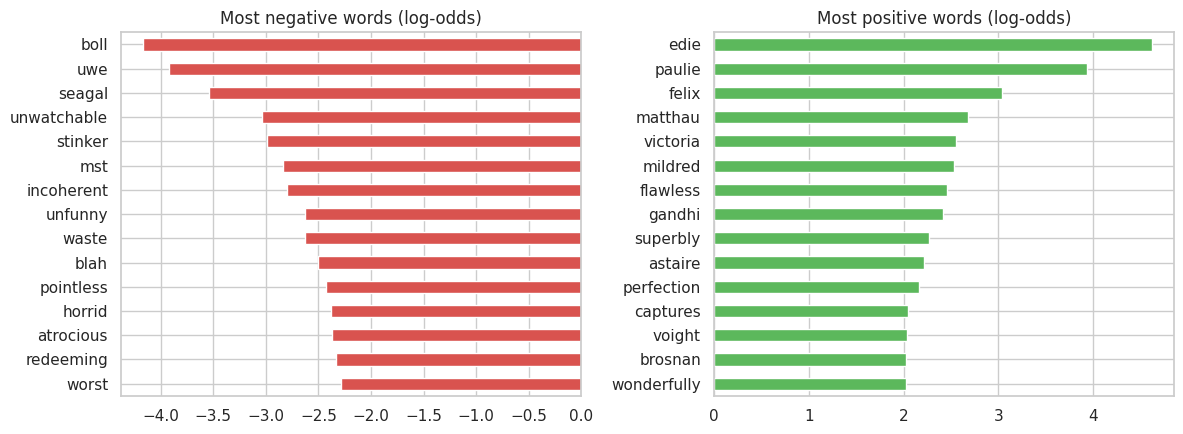

In [5]:
# most distinctive words per class (simple log-odds, after removing very rare words)
from collections import Counter
STOP = set("the a an and or of to in is it this that was for on with as but are be at by his her from i you they he she we movie film one".split())
def tokens(t): return [w for w in re.findall(r"[a-z']+", t.lower().replace("<br />", " ")) if w not in STOP and len(w) > 2]

cp, cn = Counter(), Counter()
for t, l in zip(train_texts[:25000], train_labels):
    (cp if l == 1 else cn).update(tokens(t))

vocab = [w for w in set(cp) | set(cn) if cp[w] + cn[w] >= 100]
lo = pd.Series({w: np.log((cp[w] + 1) / (cn[w] + 1)) for w in vocab}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lo.head(15)[::-1].plot.barh(ax=axes[0], color="#d9534f"); axes[0].set_title("Most negative words (log-odds)")
lo.tail(15).plot.barh(ax=axes[1], color="#5cb85c");       axes[1].set_title("Most positive words (log-odds)")
plt.tight_layout(); plt.show()

## 4. Text preprocessing pipeline

- **Standardisation:** lower-case, remove the `<br />` HTML tags, strip punctuation (keeping apostrophes, e.g. *don't*)
- **Tokenisation:** `TextVectorization` keeps the **20,000** most frequent words; everything else becomes `[UNK]`
- **Padding/truncation:** each review is fixed to **250** tokens (≈ 70% of reviews fit completely; the beginning of longer reviews is kept)
- **Validation split:** 15% of the training data is held out for early stopping; the official 25k test set is only used at the end

The vocabulary is learned from the training portion only.

In [6]:
VOCAB_SIZE = 20000
MAX_LEN = 250
EMB_DIM = 128

def custom_standardization(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, "<br />", " ")
    text = tf.strings.regex_replace(text, "[^a-z0-9' ]", " ")
    return text

vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_mode="int",
                                      output_sequence_length=MAX_LEN,
                                      standardize=custom_standardization)

tr_texts, val_texts, y_train, y_val = train_test_split(
    train_texts, train_labels, test_size=0.15, stratify=train_labels, random_state=SEED)

vectorizer.adapt(tf.constant(tr_texts))

def encode(texts):
    out = []
    for i in range(0, len(texts), 5000):
        out.append(vectorizer(tf.constant(texts[i:i + 5000])).numpy())
    return np.vstack(out).astype("int32")

X_train, X_val, X_test = encode(tr_texts), encode(val_texts), encode(test_texts)
y_test = np.asarray(test_labels)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
vocab_list = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocab_list), "| first tokens:", vocab_list[:12])

sample = tr_texts[0]
print("\nOriginal :", sample[:150].replace("<br />", " "), "...")
print("Encoded  :", X_train[0][:20], "...")
print("Decoded  :", " ".join(vocab_list[i] for i in X_train[0][:20]), "...")

Train: (21250, 250) | Val: (3750, 250) | Test: (25000, 250)
Vocabulary size: 20000 | first tokens: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this')]

Original : In director Eric Stanze's 'ISOYC, IPOYG', three men are subjected to torture at the the hands of a woman that they have all sexually abused. The first ...
Encoded  : [   8  164 2242    1    1    1  286  347   23 5118    6 1771   30    2
    2  985    5    4  252   12] ...
Decoded  : in director eric [UNK] [UNK] [UNK] three men are subjected to torture at the the hands of a woman that ...


## 5. Model architectures

All models share the same skeleton so the comparison is fair:

```
Input(250 token ids) → Embedding(20000 → 128, masks padding) → [RNN layer, 64 units] → Dropout(0.5) → Dense(64, ReLU) → Dropout(0.5) → Dense(1, sigmoid)
```

| Model | Recurrent layer | Idea |
|---|---|---|
| SimpleRNN | `SimpleRNN(64)` | Plain recurrence – suffers from vanishing gradients on long reviews |
| LSTM | `LSTM(64)` | Gated memory cell that can keep information over long spans |
| GRU | `GRU(64)` | Lighter gated unit (fewer parameters than LSTM) |
| BiLSTM | `Bidirectional(LSTM(64))` | Reads the review forwards **and** backwards |

In [7]:
def build_model(kind, units=64):
    inp = keras.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True)(inp)
    if kind == "SimpleRNN":
        x = layers.SimpleRNN(units)(x)
    elif kind == "LSTM":
        x = layers.LSTM(units)(x)
    elif kind == "GRU":
        x = layers.GRU(units)(x)
    elif kind == "BiLSTM":
        x = layers.Bidirectional(layers.LSTM(units))(x)
    else:
        raise ValueError(kind)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name=kind)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model

build_model("BiLSTM").summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train and compare the models

Early stopping on validation loss restores the best weights, so the number of epochs is chosen automatically (max 8).

In [8]:
MODELS = ["SimpleRNN", "LSTM", "GRU", "BiLSTM"]
EPOCHS, BATCH = 8, 128

trained, histories = {}, {}
for name in MODELS:
    print(f"\n===== Training {name} =====")
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(name)
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH, callbacks=cb, verbose=2)
    trained[name], histories[name] = model, h.history


===== Training SimpleRNN =====
Epoch 1/8
167/167 - 14s - 81ms/step - accuracy: 0.6110 - auc: 0.6626 - loss: 0.6526 - val_accuracy: 0.6885 - val_auc: 0.7729 - val_loss: 0.5901
Epoch 2/8
167/167 - 4s - 25ms/step - accuracy: 0.7959 - auc: 0.8663 - loss: 0.4605 - val_accuracy: 0.8125 - val_auc: 0.8891 - val_loss: 0.4324
Epoch 3/8
167/167 - 4s - 24ms/step - accuracy: 0.7488 - auc: 0.8288 - loss: 0.5396 - val_accuracy: 0.7392 - val_auc: 0.7819 - val_loss: 0.5853
Epoch 4/8
167/167 - 4s - 23ms/step - accuracy: 0.6354 - auc: 0.6875 - loss: 0.6400 - val_accuracy: 0.6605 - val_auc: 0.7277 - val_loss: 0.6053

===== Training LSTM =====
Epoch 1/8
167/167 - 11s - 67ms/step - accuracy: 0.6895 - auc: 0.7639 - loss: 0.5877 - val_accuracy: 0.8477 - val_auc: 0.9142 - val_loss: 0.3783
Epoch 2/8
167/167 - 3s - 17ms/step - accuracy: 0.8874 - auc: 0.9453 - loss: 0.2955 - val_accuracy: 0.8664 - val_auc: 0.9377 - val_loss: 0.3541
Epoch 3/8
167/167 - 4s - 21ms/step - accuracy: 0.9393 - auc: 0.9779 - loss: 0.179

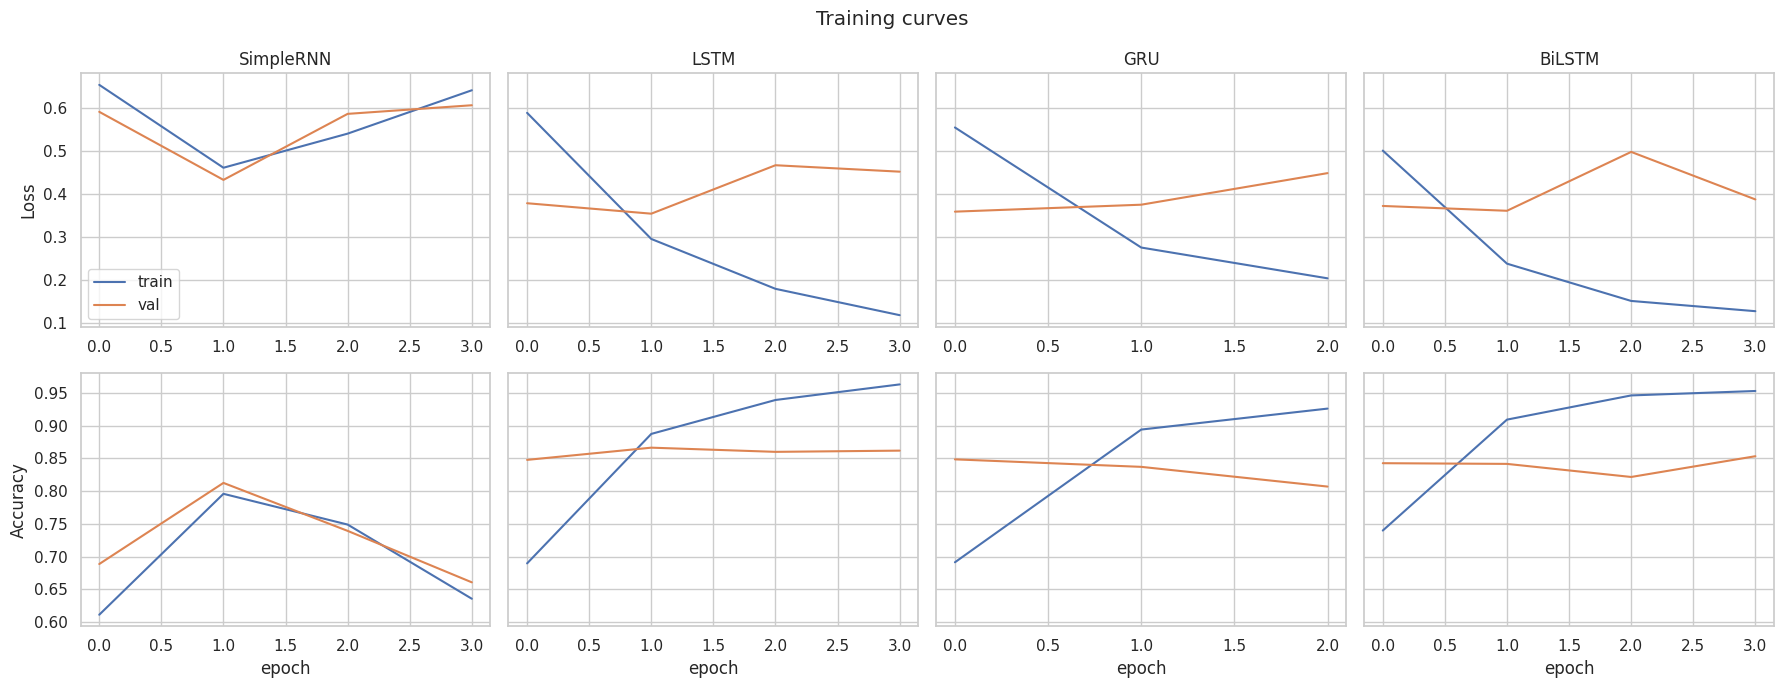

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey="row")
for j, name in enumerate(MODELS):
    h = histories[name]
    axes[0, j].plot(h["loss"], label="train"); axes[0, j].plot(h["val_loss"], label="val")
    axes[0, j].set_title(name); axes[1, j].plot(h["accuracy"], label="train"); axes[1, j].plot(h["val_accuracy"], label="val")
    axes[1, j].set_xlabel("epoch")
axes[0, 0].set_ylabel("Loss"); axes[1, 0].set_ylabel("Accuracy"); axes[0, 0].legend()
plt.suptitle("Training curves"); plt.tight_layout(); plt.show()

## 7. Evaluation on the held-out 25,000-review test set

,params,accuracy,F1,ROC_AUC,epochs_run
model,,,,,
LSTM,2613633,0.8535,0.8570,0.9284,4
BiLSTM,2667137,0.8354,0.8480,0.9257,4
GRU,2601473,0.8338,0.8218,0.9195,3
SimpleRNN,2576577,0.8027,0.7831,0.8853,4


Best model: LSTM


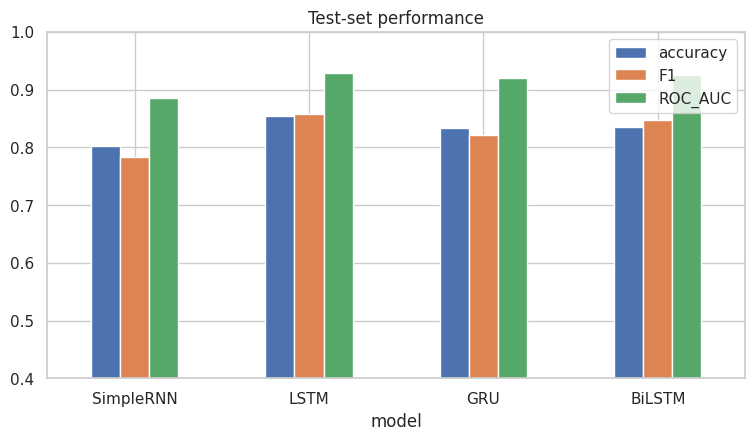

In [10]:
rows, probs = [], {}
for name, model in trained.items():
    p = model.predict(X_test, batch_size=256, verbose=0).ravel()
    pred = (p >= 0.5).astype(int)
    probs[name] = p
    rows.append({"model": name,
                 "params": model.count_params(),
                 "accuracy": accuracy_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC_AUC": roc_auc_score(y_test, p),
                 "epochs_run": len(histories[name]["loss"])})

results = pd.DataFrame(rows).set_index("model").round(4)
display(results.sort_values("accuracy", ascending=False))

best = results["accuracy"].idxmax()
print("Best model:", best)

ax = results[["accuracy", "F1", "ROC_AUC"]].plot.bar(figsize=(9, 4.5), rot=0)
ax.set_ylim(0.4, 1.0); ax.set_title("Test-set performance"); plt.show()

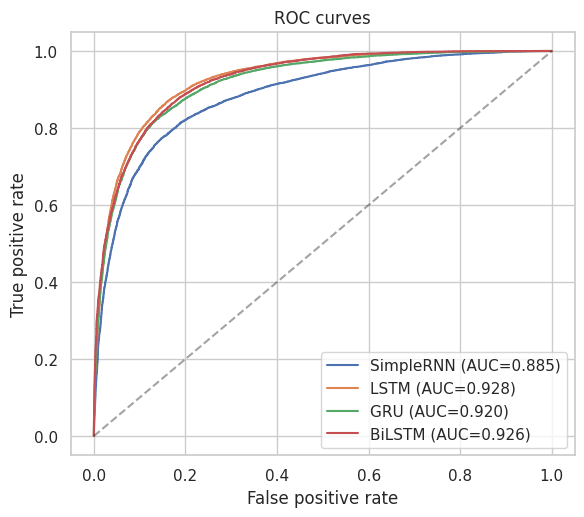

In [11]:
plt.figure(figsize=(6.5, 5.5))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC curves"); plt.legend()
plt.show()

              precision    recall  f1-score   support

    negative     0.8715    0.8294    0.8499     12500
    positive     0.8372    0.8777    0.8570     12500

    accuracy                         0.8535     25000
   macro avg     0.8543    0.8535    0.8534     25000
weighted avg     0.8543    0.8535    0.8534     25000



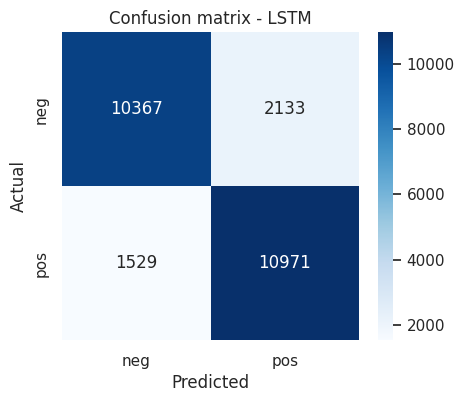

In [12]:
best_pred = (probs[best] >= 0.5).astype(int)
print(classification_report(y_test, best_pred, target_names=["negative", "positive"], digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion matrix - {best}")
plt.show()

## 8. Error analysis – where does the model go wrong?

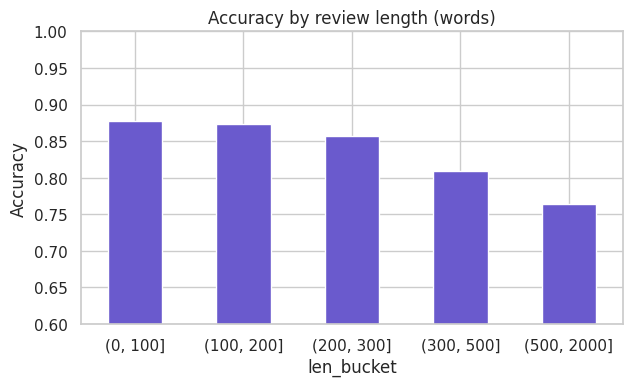

TRUE: negative | PREDICTED P(pos)=1.00
This film derives from a Long Running ITV sitcom by the same name.The Sitcom lasted for half a decade roughly and brought to our screens Rigsby,Phillip,Alan,Mrs Jones & Vienna.  Then in 1980 The film version hit the Cinemas.Now when it did,sadly Richard Beckinsale had passed away & was replaced by Only when i laugh actor Chris Strauli.  I myself felt this gave the film a different feel.I would have preferred if it wasn't shot as Richard was a key ...

TRUE: negative | PREDICTED P(pos)=1.00
This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Ricki Lake could have been better. And Johnny Depp is magnificent. He is such a beautiful man and a very talented actor. And seeing most of Johnny's movies, this is probably my favorite. I give it 9.5/10. Rent it today! ...

TRUE: negative | PREDICTED P(pos)=1.00
Less t

In [13]:
test_df = pd.DataFrame({"text": test_texts, "label": y_test, "prob_pos": probs[best]})
test_df["pred"] = (test_df["prob_pos"] >= 0.5).astype(int)
test_df["n_words"] = test_df["text"].str.split().str.len()
test_df["correct"] = test_df["pred"] == test_df["label"]

# accuracy vs. review length
test_df["len_bucket"] = pd.cut(test_df["n_words"], [0, 100, 200, 300, 500, 2000])
acc_by_len = test_df.groupby("len_bucket")["correct"].mean()
acc_by_len.plot.bar(figsize=(7, 3.8), rot=0, color="slateblue")
plt.ylim(0.6, 1); plt.ylabel("Accuracy"); plt.title("Accuracy by review length (words)"); plt.show()

# most confidently wrong predictions
wrong = test_df[~test_df["correct"]].copy()
wrong["confidence"] = (wrong["prob_pos"] - 0.5).abs()
for _, r in wrong.sort_values("confidence", ascending=False).head(4).iterrows():
    print(f"TRUE: {'positive' if r.label else 'negative'} | PREDICTED P(pos)={r.prob_pos:.2f}")
    print(r.text.replace("<br />", " ")[:450], "...\n")

## 9. Try it on your own reviews

In [14]:
def predict_sentiment(reviews, model=trained[best]):
    X = encode(list(reviews))
    p = model.predict(X, verbose=0).ravel()
    return pd.DataFrame({"review": [r[:90] + ("..." if len(r) > 90 else "") for r in reviews],
                         "P(positive)": p.round(3),
                         "sentiment": np.where(p >= 0.5, "positive", "negative")})

my_reviews = [
    "An absolute masterpiece. The acting was superb and the story kept me hooked until the very last scene.",
    "Terrible movie. The plot made no sense, the dialogue was painful and I wanted my money back.",
    "It was okay. Some nice moments but overall a bit forgettable and way too long.",
    "I did not expect to enjoy this, but it turned out to be surprisingly funny and heartfelt.",
    "Not good at all. I wouldn't recommend it to anyone.",
    "Great cast, beautiful photography, yet somehow it all felt completely hollow and boring.",
]
predict_sentiment(my_reviews)

,review,P(positive),sentiment
0,An absolute masterpiece. The acting was superb...,0.969,positive
1,"Terrible movie. The plot made no sense, the di...",0.050,negative
2,It was okay. Some nice moments but overall a b...,0.433,negative
3,"I did not expect to enjoy this, but it turned ...",0.947,positive
4,Not good at all. I wouldn't recommend it to an...,0.835,positive
5,"Great cast, beautiful photography, yet somehow...",0.416,negative


In [15]:
# Interactive: type your own review
text = input("Type a movie review: ")
display(predict_sentiment([text]))

Type a movie review: Enjoyed the movie. Will recommend to everyone


,review,P(positive),sentiment
0,Enjoyed the movie. Will recommend to everyone,0.914,positive


## 10. Save the best model

In [16]:
trained[best].save(f"imdb_sentiment_{best}.keras")

import pickle
with open("imdb_vocab.pkl", "wb") as f:
    pickle.dump({"vocab": vocab_list, "max_len": MAX_LEN}, f)
print("Saved:", f"imdb_sentiment_{best}.keras", "and imdb_vocab.pkl")

# from google.colab import files
# files.download(f"imdb_sentiment_{best}.keras"); files.download("imdb_vocab.pkl")

Saved: imdb_sentiment_LSTM.keras and imdb_vocab.pkl
